# 1. Import Libraries

## Objective

Import all required libraries for machine learning model development.

## Methodology

The notebook uses:

- Pandas and NumPy for data manipulation
- Scikit-learn for preprocessing, model training and evaluation
- Matplotlib and Seaborn for visualization
- Joblib for saving trained models

## Expected Output

All required libraries are successfully imported.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_NAME = "Personal Knowledge Decay Predictor"

matches = [
    p for p in Path("/content/drive/MyDrive").rglob(PROJECT_NAME)
    if p.is_dir()
]

PROJECT_ROOT = matches[0]

sys.path.append(str(PROJECT_ROOT))

from config import *

print("✅ Project Root :", PROJECT_ROOT)

✅ Project Root : /content/drive/MyDrive/Marwadi_uiniversity/Personal Knowledge Decay Predictor
✅ Project Root : /content/drive/MyDrive/Marwadi_uiniversity/Personal Knowledge Decay Predictor


# 1. Import Libraries

## Objective

Import all required libraries for machine learning model development.

## Methodology

The notebook uses:

- Pandas and NumPy for data manipulation
- Scikit-learn for preprocessing, model training and evaluation
- Matplotlib and Seaborn for visualization
- Joblib for saving trained models

## Expected Output

All required libraries are successfully imported.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

# 2. Load Target-Engineered Dataset

## Objective

Load the processed dataset generated in Notebook 04.

## Methodology

The dataset is read from the shared project directory.

## Expected Output

The target-engineered dataset is successfully loaded into a pandas DataFrame.

In [4]:
df = pd.read_csv(
    f"{DATA_DIR}/Processed/model_ready_dataset.csv",
    low_memory=False
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (871614, 85)


,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,Ln,MCAS,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered,future_accuracy,forget_event
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.759192485,45,1,0,0.0,0.0,NaN,0,0.789474,0
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.908767782,45,2,1,1.0,1.0,NaN,0,0.777778,0
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.969112157,45,3,2,2.0,1.0,NaN,0,0.764706,0
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.989972799,45,4,3,3.0,1.0,NaN,0,0.750000,0
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.936555224,45,5,4,4.0,1.0,NaN,0,0.800000,0


# 3. Dataset Overview

## Objective

Verify the integrity of the loaded dataset before model development.

## Methodology

The dataset dimensions, feature names and target distribution are inspected.

## Expected Output

A verified dataset ready for feature selection.

In [5]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print()

print("=" * 60)
print("Number of Features")
print("=" * 60)

print(len(df.columns))

print()

print("=" * 60)
print("Target Distribution")
print("=" * 60)

display(
    df["forget_event"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Dataset Shape
(871614, 85)

Number of Features
85

Target Distribution


,proportion
forget_event,
0,90.85
1,9.15


# 4. Feature Selection

## Objective

Select the predictor variables for model training.

## Methodology

Only historical learning features that would be available at prediction time are selected.

Identifier columns and future-derived variables are excluded to prevent data leakage.

## Expected Output

A feature matrix `X` and target vector `y`.

In [6]:
# =====================================================
# Feature Selection
# =====================================================

feature_columns = [
    "interaction_order",
    "past_attempts",
    "past_correct",
    "past_accuracy",
    "rolling_accuracy",
    "mastered"
]

X = df[feature_columns]

y = df["forget_event"]

print("Selected Features:")
print(feature_columns)

print()
print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Selected Features:
['interaction_order', 'past_attempts', 'past_correct', 'past_accuracy', 'rolling_accuracy', 'mastered']

Feature Matrix Shape : (871614, 6)
Target Shape         : (871614,)


# 5. Feature Summary

## Objective

Inspect the selected features before model training.

## Methodology

Summary statistics are generated for each selected feature to verify reasonable value ranges.

## Expected Output

Descriptive statistics of the predictor variables.

In [7]:
display(X.describe())

,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered
count,871614.000000,871614.000000,871614.000000,871614.000000,627704.000000,871614.000000
mean,23.104622,22.104622,7.022083,0.280996,0.317264,0.145497
std,32.175541,32.175541,11.348186,0.235314,0.241018,0.352601
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,4.000000,1.000000,0.111111,0.200000,0.000000
50%,12.000000,11.000000,3.000000,0.250000,0.200000,0.000000
75%,28.000000,27.000000,8.000000,0.400000,0.400000,0.000000
max,744.000000,743.000000,241.000000,1.000000,1.000000,1.000000


# 6. Train-Test Split

## Objective

Split the dataset into training and testing subsets.

## Methodology

An 80:20 split is performed with stratification on the target variable to preserve the class distribution.

The random state is fixed to ensure reproducibility.

## Expected Output

Training and testing datasets ready for model development.

In [8]:
# =====================================================
# Train-Test Split
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print()

print("Training Target Distribution")
print(y_train.value_counts(normalize=True).round(3))

print()

print("Testing Target Distribution")
print(y_test.value_counts(normalize=True).round(3))

Training Set : (697291, 6)
Testing Set  : (174323, 6)

Training Target Distribution
forget_event
0    0.909
1    0.091
Name: proportion, dtype: float64

Testing Target Distribution
forget_event
0    0.909
1    0.091
Name: proportion, dtype: float64


# 4. Feature Selection

## Objective

Select the predictor variables for model training.

## Methodology

Only historical learning features that would be available at prediction time are selected.

Identifier columns and future-derived variables are excluded to prevent data leakage.

## Expected Output

A feature matrix `X` and target vector `y`.

In [9]:
feature_columns = [
    "interaction_order",
    "past_attempts",
    "past_correct",
    "past_accuracy",
    "rolling_accuracy",
    "mastered"
]

X = df[feature_columns]

y = df["forget_event"]

print("Selected Features:")
print(feature_columns)

print()
print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Selected Features:
['interaction_order', 'past_attempts', 'past_correct', 'past_accuracy', 'rolling_accuracy', 'mastered']

Feature Matrix Shape : (871614, 6)
Target Shape         : (871614,)


# 5. Feature Summary

## Objective

Inspect the selected features before model training.

## Methodology

Summary statistics are generated for each selected feature to verify reasonable value ranges.

## Expected Output

Descriptive statistics of the predictor variables.

In [10]:
display(X.describe())

,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered
count,871614.000000,871614.000000,871614.000000,871614.000000,627704.000000,871614.000000
mean,23.104622,22.104622,7.022083,0.280996,0.317264,0.145497
std,32.175541,32.175541,11.348186,0.235314,0.241018,0.352601
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,4.000000,1.000000,0.111111,0.200000,0.000000
50%,12.000000,11.000000,3.000000,0.250000,0.200000,0.000000
75%,28.000000,27.000000,8.000000,0.400000,0.400000,0.000000
max,744.000000,743.000000,241.000000,1.000000,1.000000,1.000000


# 6. Train-Test Split

## Objective

Split the dataset into training and testing subsets.

## Methodology

An 80:20 split is performed with stratification on the target variable to preserve the class distribution.

The random state is fixed to ensure reproducibility.

## Expected Output

Training and testing datasets ready for model development.

In [11]:
# =====================================================
# Train-Test Split
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print()

print("Training Target Distribution")
print(y_train.value_counts(normalize=True).round(3))

print()

print("Testing Target Distribution")
print(y_test.value_counts(normalize=True).round(3))

Training Set : (697291, 6)
Testing Set  : (174323, 6)

Training Target Distribution
forget_event
0    0.909
1    0.091
Name: proportion, dtype: float64

Testing Target Distribution
forget_event
0    0.909
1    0.091
Name: proportion, dtype: float64


# 7. Feature Scaling

## Objective

Standardize the selected features before training models that are sensitive to feature scale.

## Methodology

A StandardScaler is fitted using the training data and then applied to both training and testing datasets.

## Expected Output

Scaled training and testing feature matrices.

In [12]:
# =====================================================
# Feature Scaling and Imputation
# =====================================================

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Impute missing values (e.g., with the mean)
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the imputed features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Imputation and Scaling completed.")
print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

Imputation and Scaling completed.
Training Shape : (697291, 6)
Testing Shape  : (174323, 6)


# 8. Baseline Model – Logistic Regression

## Objective

Train a baseline classification model for predicting forgetting events.

## Methodology

A Logistic Regression classifier is trained using the standardized training data.

The trained model predicts whether a student is likely to experience a forgetting event.

## Expected Output

A trained baseline model.

In [13]:
# =====================================================
# Logistic Regression Model
# =====================================================

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("✅ Logistic Regression trained successfully.")

✅ Logistic Regression trained successfully.


# 9. Model Prediction

## Objective

Generate predictions using the trained Logistic Regression model.

## Methodology

The trained model predicts both class labels and class probabilities for the testing dataset.

## Expected Output

Predicted class labels and prediction probabilities.

In [14]:
# =====================================================
# Predictions
# =====================================================

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed.")

Prediction completed.


# 10. Model Evaluation

## Objective

Evaluate the predictive performance of the Logistic Regression model.

## Methodology

The following metrics are computed:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics provide a comprehensive assessment of model performance.

## Expected Output

Classification metrics for the baseline model.

In [15]:
# =====================================================
# Evaluation Metrics
# =====================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(results.round(4))

,Metric,Value
0,Accuracy,0.9513
1,Precision,0.6816
2,Recall,0.8767
3,F1 Score,0.7669
4,ROC AUC,0.9807


In [16]:
# =====================================================
# Classification Report
# =====================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.96      0.97    158380
           1       0.68      0.88      0.77     15943

    accuracy                           0.95    174323
   macro avg       0.83      0.92      0.87    174323
weighted avg       0.96      0.95      0.95    174323



# 11. Confusion Matrix

## Objective

Visualize the prediction results using a confusion matrix.

## Methodology

A confusion matrix is generated to summarize correct and incorrect classifications.

## Expected Output

Heatmap visualization of prediction outcomes.

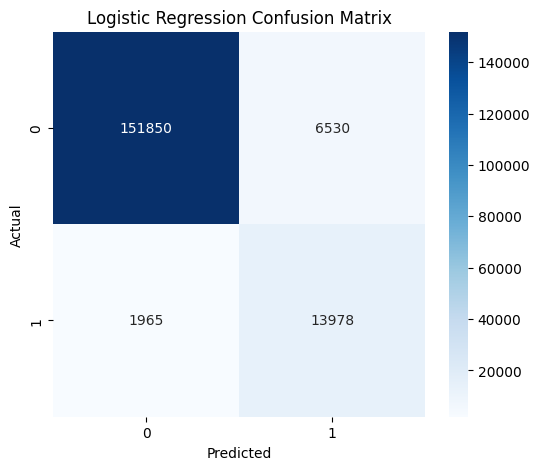

In [17]:
# =====================================================
# Confusion Matrix
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# 12. Feature Coefficients

## Objective

Interpret the contribution of each feature in the Logistic Regression model.

## Methodology

Model coefficients are extracted and ranked according to their magnitude.

## Expected Output

Feature coefficient table.

In [18]:
# =====================================================
# Feature Coefficients
# =====================================================

coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

display(coef_df)

,Feature,Coefficient
5,mastered,4.669651
0,interaction_order,0.411319
1,past_attempts,0.411319
4,rolling_accuracy,-0.217865
3,past_accuracy,-0.378388
2,past_correct,-0.566028


# 13. Random Forest Model

## Objective

Train a Random Forest classifier for predicting student forgetting events.

## Methodology

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture non-linear relationships between features.

## Expected Output

A trained Random Forest model.

In [19]:
# =====================================================
# Random Forest Model
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


# 14. Random Forest Prediction

## Objective

Generate predictions using the trained Random Forest model.

## Methodology

The trained model predicts both class labels and class probabilities for the testing dataset.

## Expected Output

Predicted labels and probabilities.

In [20]:
# =====================================================
# Random Forest Prediction
# =====================================================

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Prediction completed.")

Prediction completed.


# 15. Random Forest Evaluation

## Objective

Evaluate the predictive performance of the Random Forest model.

## Methodology

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## Expected Output

Evaluation metrics for Random Forest.

In [21]:
# =====================================================
# Random Forest Evaluation
# =====================================================

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_auc = roc_auc_score(y_test, rf_prob)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

display(rf_results.round(4))

,Metric,Random Forest
0,Accuracy,0.9501
1,Precision,0.6834
2,Recall,0.8461
3,F1 Score,0.7561
4,ROC AUC,0.9794


# 19. Model Comparison

## Objective

Compare the performance of the Logistic Regression and Random Forest models.

## Methodology

Both models are evaluated using the same performance metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The model with the strongest overall performance is selected for deployment.

## Expected Output

A comparison table of both machine learning models.

In [22]:
# =====================================================
# Model Comparison
# =====================================================

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

display(comparison.round(4))

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9513,0.9501
1,Precision,0.6816,0.6834
2,Recall,0.8767,0.8461
3,F1 Score,0.7669,0.7561
4,ROC AUC,0.9807,0.9794


# 20. Best Model Selection

## Objective

Select the best-performing model for deployment.

## Methodology

The model with the higher ROC-AUC score is selected as the final prediction model.

## Expected Output

Name of the selected model.

In [23]:
# =====================================================
# Best Model Selection
# =====================================================

if rf_auc > roc_auc:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = log_model
    best_model_name = "Logistic Regression"

print("=" * 50)
print("Selected Model")
print("=" * 50)
print(best_model_name)

Selected Model
Logistic Regression


# 21. Save Best Model

## Objective

Save the selected machine learning model for future inference.

## Methodology

The selected model is serialized using Joblib and stored in the project directory.

## Expected Output

Saved model file.

In [24]:
# =====================================================
# Save Best Model
# =====================================================

MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_DIR / "best_model.pkl")

print("✅ Best model saved successfully.")

✅ Best model saved successfully.


In [25]:
# =====================================================
# Save Scaler
# =====================================================

if best_model_name == "Logistic Regression":
    joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
    print("Scaler saved.")

Scaler saved.


In [26]:
# =====================================================
# Save Feature List
# =====================================================

import json

with open(MODEL_DIR / "selected_features.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print("✅ Feature list saved successfully.")

✅ Feature list saved successfully.


In [31]:
# =====================================================
# Save Model Comparison
# =====================================================

# Define RESULT_DIR
RESULT_DIR = PROJECT_ROOT / "results"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    RESULT_DIR / "model_comparison.csv",
    index=False
)

print("✅ Model comparison saved successfully.")

✅ Model comparison saved successfully.


# Notebook Summary

This notebook developed and compared machine learning models for predicting student forgetting events.

The following tasks were completed:

- Feature selection
- Train-test split
- Feature scaling
- Logistic Regression model training
- Random Forest model training
- Performance evaluation
- Model comparison
- Best model selection
- Model persistence

The selected model will be used in the next notebook for detailed evaluation and deployment.